In [1]:
FW_DIR = "../fw/victims/kyber_cpapke_dec_ss"
BIN_FILE = f"{FW_DIR}/kyber_cpapke_dec_ss.bin"
BOOTLOADER = "python3 ../../sdk/toolchain/bootloader.py"
BS_FILE = "../vivado/risqrypt_cw305.runs/impl_1/fpga_top.bit"
TARGET_PLATFORM = 'CW305_100t'
KYBER_K = 3

In [2]:
import sys
sys.path.insert(0, "../")

from host.CW305_rq import CW305_rq

In [3]:
import chipwhisperer as cw

In [4]:
scope = cw.scope()
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

In [5]:
target = cw.target(scope, CW305_rq, force=True, fpga_id='100t', platform='cw305', bsfile=BS_FILE)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information


In [6]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(10E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [8]:
%%bash -s "$FW_DIR" "$KYBER_K"
cd $1
make KYBER_K=$2

-DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolchain/linksc.ld -flto -ffunction-sections -fdata-sections -nostartfiles -o kyber_cpapke_dec_ss.elf
/opt/riscv/bin/riscv64-unknown-elf-gcc kyber_cpapke_dec_ss.c ../../../../fw/kyber_hw/indcpa.c ../../../../fw/kyber_hw/poly.c ../../../../fw/kyber_hw/polyvec.c ../../../../fw/kyber_hw/pack.c ../../../../fw/kyber_hw/symmetric.c ../../../../fw/kyber_hw/cbd.c ../../driver/cw305.c ../../simpleserial/simpleserial_cw305_rq.c ../../../../sdk/toolchain/start.s ../../../../sdk/lib/util.c ../../../../sdk/lib/uart.c ../../../../sdk/lib/timer.c ../../../../sdk/lib/gpio.c ../../../../sdk/lib/keccak.c ../../../../sdk/lib/ntt_lite.c ../../../../sdk/lib/x2x.c -DKYBER_K=3 -DSS_VER=1 -O3 -I../../../../fw/kyber_hw -I../../driver -I../../simpleserial -I../../../../sdk/lib -march=rv32im -mabi=ilp32 -mstrict-align -T ../../../../sdk/toolch

In [9]:
%%bash -s "$BIN_FILE" "$BOOTLOADER"
$2 -f $1 -q

Successfully connected to /dev/ttyUSB0
Sent: -p
Waiting for opcodes...
Sending file: ../fw/victims/kyber_cpapke_dec_ss/kyber_cpapke_dec_ss.bin


../fw/victims/kyber_cpapke_dec_ss/kyber_cpapke_dec_ss.bin: 100%|██████████| 63.0k/63.0k [01:04<00:00, 970B/s]  


File transmission complete.
Serial port closed.


In [10]:
if scope._is_husky:
    scope.clock.clkgen_freq = 40e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 4
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.adc_src = "extclk_x4"

In [11]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

In [12]:
scope.adc.samples = 50000
scope.gain.db = 15

In [13]:
target.output_len = 16

In [14]:
if KYBER_K == 2:
    from kyber_py.kyber.default_parameters import Kyber512 as kyber_py
elif KYBER_K == 3:
    from kyber_py.kyber.default_parameters import Kyber768 as kyber_py
elif KYBER_K == 4:
    from kyber_py.kyber.default_parameters import Kyber1024 as kyber_py
else:
    raise ValueError("Invalid KYBER_K")

In [15]:
import os
from Crypto.Hash import SHA3_256, SHAKE256


def set_key(seed = os.urandom(32)):
    def rng(len):
        assert len == 32
        return seed
    kyber_py.random_bytes = rng
    target.simpleserial_write('k', seed)
    pk, sk = kyber_py._cpapke_keygen()
    print("Secret key:", sk.hex())
    print("Public key:", pk.hex())
    sk_hash_host = SHA3_256.new(sk).digest()[:16]
    sk_hash_dut = target.simpleserial_read('r', 16)
    assert sk_hash_host == sk_hash_dut, "Secret key hash mismatch!"
    return sk


def ct_size():
    pk, _ = kyber_py._cpapke_keygen()
    ct = kyber_py._cpapke_enc(pk, os.urandom(32), os.urandom(32))
    return len(ct)

CIPHER_SIZE = ct_size()

def ct_from_seed(seed):
    return SHAKE256.new(seed).read(CIPHER_SIZE)

In [82]:
set_key()

Secret key: 396b1a34c45c7f5c5b1b09751606c41c8b19bbfb7096754cc85a726e367aab7ca41ef8c218285d25acaa056ba5cf86bed55ace58b42c3ba73c5c8636ce691e04f9b2475b47375303ccc6c0ce2b3929148e61c955beba41d93a627951c7ec4a0f34298ab3f46cb02b57c9d62a8878ce1c0586f05841de000c63ab34e3a1c3c942505f19b679d4163917b6fada9f5773548eb9b33ac3665fd668f45234e025bed286c2fe787e80ac59dc53a2f1aa7bf9a852bcf8cb0572ac25771c67201df7ec46ce8cc62af55c6f634299c455558a6dada31a48124e516751d0f59d4fc672924b139a5c5a37769a44c4847aba929d923377441a9068073d16c0899689781bcbc9012587c340b98cb9db65242c522d3eb866872b72a2e437d5b142e02a0a4763669c89ae27111cc15015e3e6b0bc490214fb8415971e36282a124c427d800390c1467ef8a34812a458fa8e3ba7a926809403e52a29b8682b9c05807c3c31746691d902bb9c3f3471a8acc650f80042666874e80558416335e2db372fa52c45fbbf756b5308331c81786eacf48f2a35990a6c47e714924ffb2764b44b55ec1c8a50ba835a70e60828581b9a30496abeb48fef6bac88c8115d472617a127d5235e9d10a6cf60aaf70008a9a3bafbf7ac1bc479cc92a8d47c612b0b81c25b99f3177f1b56ac6f8a92dbb47ffe20a4eab5

b'9k\x1a4\xc4\\\x7f\\[\x1b\tu\x16\x06\xc4\x1c\x8b\x19\xbb\xfbp\x96uL\xc8Zrn6z\xab|\xa4\x1e\xf8\xc2\x18(]%\xac\xaa\x05k\xa5\xcf\x86\xbe\xd5Z\xceX\xb4,;\xa7<\\\x866\xcei\x1e\x04\xf9\xb2G[G7S\x03\xcc\xc6\xc0\xce+9)\x14\x8ea\xc9U\xbe\xbaA\xd9:byQ\xc7\xecJ\x0f4)\x8a\xb3\xf4l\xb0+W\xc9\xd6*\x88x\xce\x1c\x05\x86\xf0XA\xde\x00\x0cc\xab4\xe3\xa1\xc3\xc9BP_\x19\xb6y\xd4\x169\x17\xb6\xfa\xda\x9fWsT\x8e\xb9\xb3:\xc3f_\xd6h\xf4R4\xe0%\xbe\xd2\x86\xc2\xfex~\x80\xacY\xdcS\xa2\xf1\xaa{\xf9\xa8R\xbc\xf8\xcb\x05r\xac%w\x1cg \x1d\xf7\xecF\xce\x8c\xc6*\xf5\\ocB\x99\xc4UU\x8am\xad\xa3\x1aH\x12NQgQ\xd0\xf5\x9dO\xc6r\x92K\x13\x9a\\Z7v\x9aD\xc4\x84z\xba\x92\x9d\x923wD\x1a\x90h\x07=\x16\xc0\x89\x96\x89x\x1b\xcb\xc9\x01%\x87\xc3@\xb9\x8c\xb9\xdbe$,R->\xb8f\x87+r\xa2\xe47\xd5\xb1B\xe0*\nGcf\x9c\x89\xae\'\x11\x1c\xc1P\x15\xe3\xe6\xb0\xbcI\x02\x14\xfb\x84\x15\x97\x1e6(*\x12LB}\x80\x03\x90\xc1F~\xf8\xa3H\x12\xa4X\xfa\x8e;\xa7\xa9&\x80\x94\x03\xe5*)\xb8h+\x9c\x05\x80|<1tf\x91\xd9\x02\xbb\x9c?4q\xa8\xac\xc6P\xf8\x00B

In [83]:
seed = os.urandom(16)
target.simpleserial_write('p', seed)
temp = ct_from_seed(seed)
print(temp.hex())
target.simpleserial_read('r', 16)

9d5b6d1e7257f66f7afb5f36963f68db4ec141361f06765dd0090f14a3974781f2648f6e129e127911677da2e52291dfc6520053ea21d63d5224813feac942cf7785ad664a58e895beee6737aa0a02a1bbef955ee58e7e3dbe0ea7f80847c7a4e81b132a1994dbde1151bc127640ba4267d8b37942f1875a01f210efcaaf235597a8338d81d2df84450cae5a94d8df266473e805911bb8641e8e451b1d5b5cb31457859daa00df3236ccd16309fbcec110d92ed17099c2c1dff7981e8e2759608ddafc12878727cbd002fba48378f4aeaadda5633bcd836b8f7af83a29e4d7dbd60bea1dbc14d86f84d805683e2076bd78d68586072743614d82c5fb7640c98c1262b4f19fe6e8ff39879a537a2efc311ed97299b88bf400dbf3218a9155c966b3019d666a077ba64b37c5480a967b3c2d65e1aedc811a89781dc7aa0d470da74f1fd0cc3c05d4aa6ad965bf9b29cbeab3e778b40d14707e37f34fae85d95fda579839a77124f91a5273f1fe6be708aaa9c26536e8e9d22d63f494db6de3755504292a15e021590c49e708370594427e70171e2c5f2831314389f60339d379ccc25b3f01a0e415709e32fa633a56e4acb7d0a836768034421f6b4375006bc470836b3edc99188fe91d4afdd0207b912787614c9691785a8d8ba8c6ed835477ca4af11a35f908083c144afb41bfc7151d7e035237

bytearray(b'\xc8\x8e\xd5\x901\xc8\xe0g\xbfqc\x83\xb6\xf7\x1f\xb8')

In [16]:
from tqdm.notebook import tnrange
import numpy as np
import estraces


N = 1000  # Number of traces

sk = set_key()

traces = []
c_arr = []
keys = []

for i in tnrange(N, desc='Capturing traces'):
    # run aux stuff that should come before trace here

    seed = os.urandom(16)
    ret = cw.capture_trace(scope, target, seed, None)
    if not ret:
        print("Failed capture")
        continue

    ct = ct_from_seed(seed)
    keys.append(np.frombuffer(sk, dtype=np.uint8))
    ret.textout
    m = kyber_py._cpapke_dec(sk, ct)[:target.output_len]
    assert m == ret.textout, "Decrypted message mismatch!"
    c_arr.append(np.frombuffer(ct, dtype=np.uint8))
    traces.append(ret.wave)


ths = estraces.read_ths_from_ram(np.array(traces), k=np.array(keys), c=np.array(c_arr))

print(ths)

Secret key: 10805a26623e3d9394134133425a7e26f09d46dc1902333eec8b01c4d412d92289e93914db3c311d25896f60bd23d2be2df441ac5412971ca6bd4136d0292c478c0b1bb07e7751166ca57e243a4e9c12419a44c0c79c488043432a2234fe2140b76ccd7038a6a0461c9047cd9eb0ab007d143c7420ef549aa923a10a7b362dfabe3372bd9e1a110bb6b5c98b892b7429fd551204256b7e3caa415362356b5260a2a4a33a5798b172fe0c261e9c72e441c53cd3c2a3b30541e59f9d294a23f244bac67da5a52da3c14f2f4c7ea53237c190af76181babb4612ad86075fb398dfb5fd27975cb04b25f98115a01542296a77d7a0304eb09cebb44b08686429a8012796ef74869750c02bdea8897ab7ddbd3b0d6450122c1398193a04f47a778d769fff39f9349b9a277b8d93c9c6e9a6a0a0ab0d3f5a1460939a4c3b067584e0f555db21a5ea8e7297c935476502743e0b6744a7fe28c473dca397211014fa7723614780d14c58df06fcae88fa00aabd3f17bda723a4d368294c356298c6b2ec97156c330ae23a653259a3e625c0fa171d5113604d23b70f01740ea6ca9d245d41a60a1138174bb20b1e253221187a1b77797537644192b3dd7c790e3c831e8ce2cc1b42c6a14182a542ff9216d34b90213b5d8989fcd023120b43aa22618bbd6b5f975031d26a0d360cddf527ddd8a

Capturing traces:   0%|          | 0/1000 [00:00<?, ?it/s]

Trace Header Set:
Name.............: RAM Format THS
Reader...........: RAM reader with 1000 traces. Samples shape: (1000, 50000) and metadatas: ['k', 'c']
k................: uint8
c................: uint8



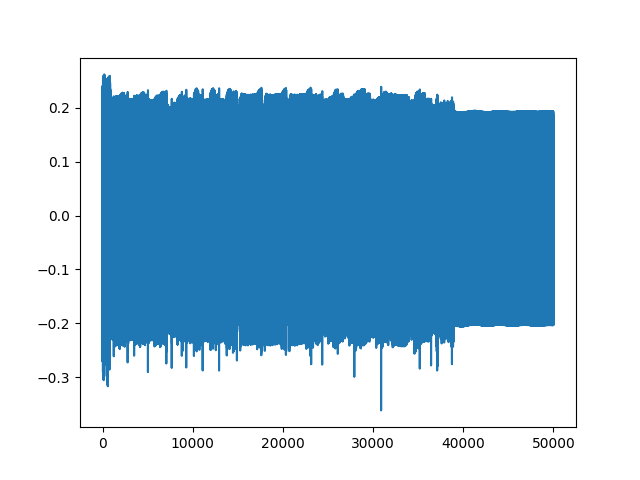

In [18]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

%matplotlib widget

mean_trace = np.mean(np.array(traces), axis=0)
ax.plot(mean_trace)

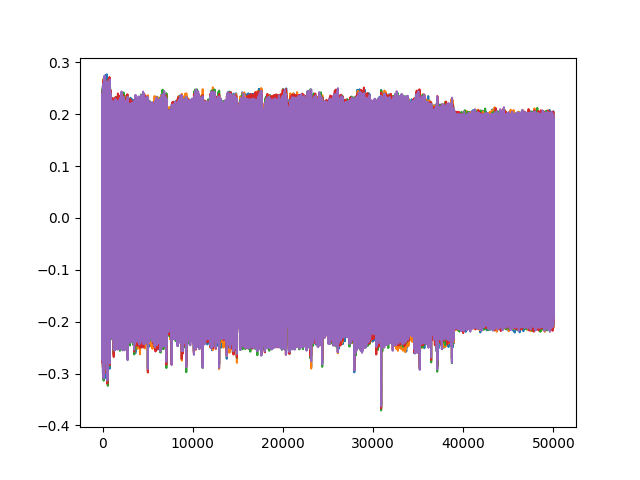

In [19]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()

for i in range(5):
    ax.plot(traces[i])

In [22]:
import scared

@scared.reverse_selection_function
def select_c(c):
    return c[:,:32]


cpa_reverse = scared.CPAReverse(selection_function=select_c, model=scared.HammingWeight(expected_dtype='uint8'))


container = scared.Container(ths)
cpa_reverse.run(container)


In [ ]:
fig, ax = plt.subplots()

for i in range(len(cpa_reverse.results)):
    ax.plot(cpa_reverse.results[i])